# CA2 Part 1: Machine Learning on the OASIS-2 Dementia Dataset

## Dataset Overview 
This set consists of a longitudinal collection of 150 subjects aged 60 to 96. Each subject was scanned on two or more visits, separated by at least one year for a total of 373 imaging sessions. For each subject, 3 or 4 individual T1-weighted MRI scans obtained in single scan sessions are included. The subjects are all right-handed and include both men and women. 72 of the subjects were characterized as nondemented throughout the study. 64 of the included subjects were characterized as demented at the time of their initial visits and remained so for subsequent scans, including 51 individuals with mild to moderate Alzheimer’s disease. Another 14 subjects were characterized as nondemented at the time of their initial visit and were subsequently characterized as demented at a later visit. [Link here](https://sites.wustl.edu/oasisbrains/home/oasis-2/)


## Question 1: Import Data
Import relevant libraries and load the dataset

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GroupShuffleSplit,
    GroupKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)



df = pd.read_csv("oasis_longitudinal_demographics.csv", encoding="utf-8-sig")
df.head()


,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


## Question 2: Data Description

Display data attributes using data visualization libraries/modules. You must use text, code, and visualization tools and comment on Data features suitable for analysis.


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Subject ID  373 non-null    object 
 1   MRI ID      373 non-null    object 
 2   Group       373 non-null    object 
 3   Visit       373 non-null    int64  
 4   MR Delay    373 non-null    int64  
 5   M/F         373 non-null    object 
 6   Hand        373 non-null    object 
 7   Age         373 non-null    int64  
 8   EDUC        373 non-null    int64  
 9   SES         354 non-null    float64
 10  MMSE        371 non-null    float64
 11  CDR         373 non-null    float64
 12  eTIV        373 non-null    int64  
 13  nWBV        373 non-null    float64
 14  ASF         373 non-null    float64
dtypes: float64(5), int64(5), object(5)
memory usage: 43.8+ KB


### Dataset structure
The dataset is organized with multiple columns capturing various demographic, clinical, and imaging data for each participant. The following table provides an explanation of each column and the types of values they contain:

| Column | Meaning | Value | DataType |
|--------|---------|-------|----------|
|Subject ID |	Unique identifier for each participant | Example: OAS2_0001 | String/Text |
|MRI ID |	Unique identifier for each MRI scan session for a participant |	Example: OAS2_0001_MR1 | String/Text |
|Group |	Clinical status of the participant at the time of the scan |	Nondemented, Demented or Converted | String/Text |
|Visit |	The visit number for the MRI session | Example: 1 | Integer |
|MR Delay	| Delay in days between the first visit and the current MRI session |	Example: 590 | Integer |
|M/F |	Gender of the participant |	M (Male) or F (Female) | String/Text |
|Hand	| Dominant hand of the participant |	R (Right-handed) or L (Left-handed) | String/Text |
|Age |	Age of the participant at the time of the MRI session |	Example: 78 | Integer |
|EDUC |	Years of Education |	Range: 0 to highest recorded value | Integer |
|SES |	Socioeconomic Status |	Range: 1 (lowest) to 5 (highest) | Integer |
|MMSE |	Mini Mental State Examination score |	Range: 0 to 30. Where a value lower than 24 indicates cognitive impairment  | Integer |
|CDR | Clinical Dementia Rating |	0 (no dementia), 0.5 (very mild AD), 1 (mild AD), 2 (moderate AD) | Float/Decimal |
|eTIV |	Estimated Total Intracranial Volume (mm³) |	Example: 1529 | Integer |
|nWBV	| Normalized Whole Brain Volume	| Percentage of all voxels labeled as gray or white matter | Float/Decimal |
|ASF |	Atlas Scaling Factor | Computed scaling factor transforming native-space brain and skull to the atlas target | Float/Decimal |

In [4]:
df.describe()

,Visit,MR Delay,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
count,373.000000,373.000000,373.000000,373.000000,354.000000,371.000000,373.000000,373.000000,373.000000,373.000000
mean,1.882038,595.104558,77.013405,14.597855,2.460452,27.342318,0.290885,1488.128686,0.729568,1.195461
std,0.922843,635.485118,7.640957,2.876339,1.134005,3.683244,0.374557,176.139286,0.037135,0.138092
min,1.000000,0.000000,60.000000,6.000000,1.000000,4.000000,0.000000,1106.000000,0.644000,0.876000
25%,1.000000,0.000000,71.000000,12.000000,2.000000,27.000000,0.000000,1357.000000,0.700000,1.099000
50%,2.000000,552.000000,77.000000,15.000000,2.000000,29.000000,0.000000,1470.000000,0.729000,1.194000
75%,2.000000,873.000000,82.000000,16.000000,3.000000,30.000000,0.500000,1597.000000,0.756000,1.293000
max,5.000000,2639.000000,98.000000,23.000000,5.000000,30.000000,2.000000,2004.000000,0.837000,1.587000


### Statistic summary
- **Dataset size**
  - 373 participant visits in total
  - Some variables (SES, MMSE) have slightly fewer records

- **Visit**
  - Average number of visits per participant: ~2
  - Minimum: 1 visit
  - Maximum: 5 visits

- **MR Delay (days between visit and MRI)**
  - Average delay: ~595 days
  - Median delay: ~552 days
  - Some scans taken on the same day (0 days)
  - Longest delay: ~2639 days

- **Age (years)**
  - Average age: ~77 years
  - Most participants are between 71 and 82 years old
  - Youngest: 60 years
  - Oldest: 98 years

- **Education (years)**
  - Average education: ~15 years
  - Most participants have 12–16 years of education
  - Range: 6 to 23 years

- **Socioeconomic Status (SES)**
  - Average SES score: ~2.5
  - Most values fall between 2 and 3
  - Range: 1 (highest SES) to 5 (lowest SES)

- **MMSE (cognitive score)**
  - Average MMSE score: ~27
  - Median score: 29
  - Scores range from 4 to 30
  - Lower scores indicate worse cognitive function

- **CDR (Clinical Dementia Rating)**
  - Average CDR: ~0.29
  - Median CDR: 0 (no dementia)
  - Values range from 0 to 2
  - Higher values indicate more severe dementia

- **eTIV (estimated total intracranial volume)**
  - Average eTIV: ~1488


In [5]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

SES           19
MMSE           2
Subject ID     0
MRI ID         0
Group          0
Visit          0
MR Delay       0
M/F            0
Hand           0
Age            0
EDUC           0
CDR            0
eTIV           0
nWBV           0
ASF            0
dtype: int64

In [6]:
df['Group'].value_counts() #get the count of each class in the target variable

Group
Nondemented    190
Demented       146
Converted       37
Name: count, dtype: int64

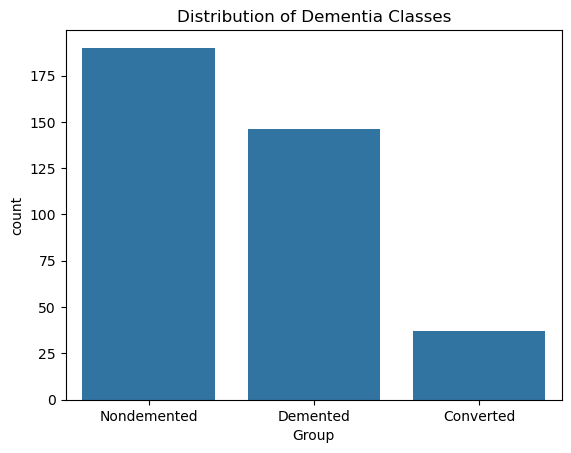

In [7]:
sns.countplot(data=df, x='Group')
plt.title("Distribution of Dementia Classes")
plt.show()

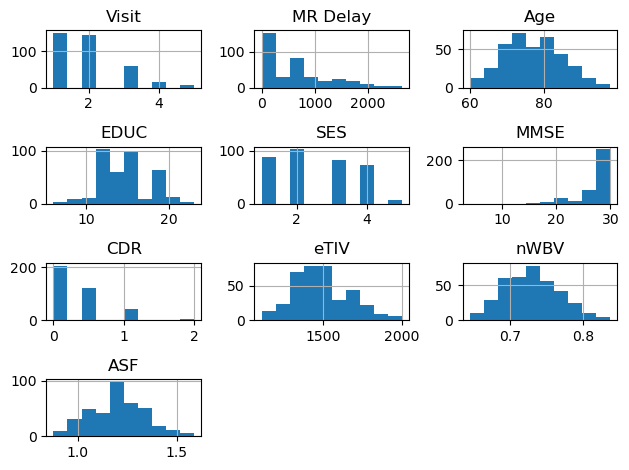

In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].hist()
plt.tight_layout()
plt.show()

Some of the histograms are centered but some like MMSe are majorly skewed. standardisation is applied later to the variables to help solve this, this also shows some outliers but as it is a clinical data outliers arent handled. 

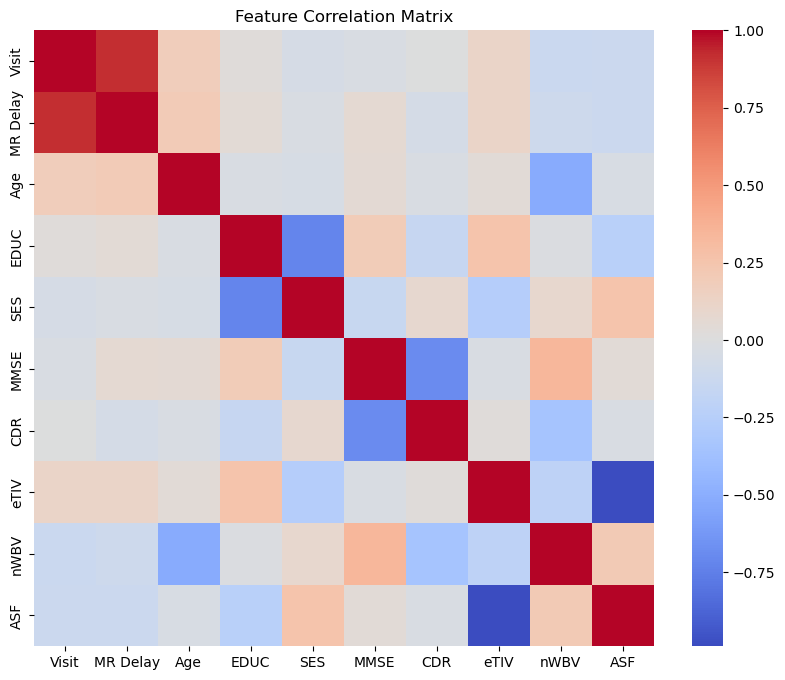

In [9]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Feature Correlation Matrix")
plt.show()

## Question 3: Model Building

Create / select a baseline ML model. Determine the impact of selected ML model/models and interpret the best model with parameters.


In [10]:
# trgt variable
target = "Group"

# Drop ID-like columns (not useful for prediction)
drop_cols = ["Subject ID", "MRI ID", "Group"]

X = df.drop(columns=drop_cols)
y = df[target]

X.head()

,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


Identifiers like **Subject ID** and **MRI ID** are removed from the feature set because they do not contain significant predictive information about dementia status, despite the fact that the dataset is longitudinal and includes repeated measurements for every subject.

By adding these identifiers to the model, the model would be able to memorize specific subjects instead of learnin patterns, which would result in overfitting and poor generalization to new data.

In [11]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Show mapping
dict(zip(le.classes_, le.transform(le.classes_)))

{'Converted': 0, 'Demented': 1, 'Nondemented': 2}

the target variable is encoded into numerical form to make it compatible

In [12]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['Visit', 'MR Delay', 'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF']
Categorical features: ['M/F', 'Hand']


In [13]:
groups = df["Subject ID"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y_encoded, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (297, 12)
Test size: (76, 12)


A group-based split is used to ensure that data from the same subject does not appear in both training and testing sets. This prevents data leakage and ensures a more realistic evaluation of model performance.

In [14]:

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
    
    
])

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

baseline_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Visit', 'MR Delay', 'Age',
                                                   'EDUC', 'SES', 'MMSE', 'CDR',
                                                   'eTIV', 'nWBV', 'ASF']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['M/F', 'Hand'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

Using a pipeline is helpful because it keeps the workflow clean and consistent. It also ensures that the same preprocessing steps are applied to both training and test data, which helps avoid mistakes and improves the reliability of the model, 

References: https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html , https://github.com/CrisCorreaS/AD-prediction-classification-models/blob/main/data-training_oasis2.ipynb , https://www.datacamp.com/tutorial/sklearn-linear-regression

In [15]:

y_pred = baseline_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8552631578947368
Balanced Accuracy: 0.715130023640662
F1 Score: 0.8148138411296305

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.17      0.29        12
           1       0.77      1.00      0.87        17
           2       0.88      0.98      0.93        47

    accuracy                           0.86        76
   macro avg       0.89      0.72      0.70        76
weighted avg       0.88      0.86      0.81        76



The baseline logistic regression model provides an initial benchmark for classification performance. While it offers reasonable results, more complex models should hopefully improve performance by capturing non-linear relationships in the data.


## Question 4: Model Evaluation, Comparison, and Hyperparameter Tuning

This section compares multiple machine learning models using cross-validation, evaluates their predictive performance, and applies hyperparameter tuning to improve results. The best-performing model is then selected and assessed on the test set.

References: https://www.geeksforgeeks.org/machine-learning/random-forest-hyperparameter-tuning-in-python/ ; https://towardsdatascience.com/hyperparameter-tuning-in-python-21a76794a1f7/#:~:text=And%20for%20this%20purpose%2C%20we,of%20trees%20in%20our%20forest.&text=We%20have%20three%20methods%20of,Random%20search%2C%20and%20Informed%20search. ; https://towardsdatascience.com/hyperparameter-tuning-in-python-21a76794a1f7/ ; https://www.geeksforgeeks.org/machine-learning/hyperparameter-tuning/ ; https://www.geeksforgeeks.org/machine-learning/how-to-optimize-logistic-regression-performance/

In [22]:

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42)
}

best_models = {}


In [23]:
cv = GroupKFold(n_splits=5)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_weighted": "f1_weighted"
}

In [24]:
results = []

train_groups = groups.iloc[train_idx]

for model_name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])
    
    cv_scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        groups=train_groups,
        scoring=scoring,
        n_jobs=-1
    )
    
    results.append({
        "model": model_name,
        "cv_accuracy_mean": cv_scores["test_accuracy"].mean(),
        "cv_balanced_accuracy_mean": cv_scores["test_balanced_accuracy"].mean(),
        "cv_f1_weighted_mean": cv_scores["test_f1_weighted"].mean()
    })

cv_results = pd.DataFrame(results).sort_values(
    by="cv_balanced_accuracy_mean",
    ascending=False
).reset_index(drop=True)

cv_results

,model,cv_accuracy_mean,cv_balanced_accuracy_mean,cv_f1_weighted_mean
0,Logistic Regression,0.912147,0.772272,0.888467
1,HistGradientBoosting,0.878701,0.728804,0.868825
2,Random Forest,0.908701,0.726190,0.871150


The models are compared using grouped cross-validation to ensure that repeated records from the same subject remain within the same fold. Balanced accuracy is particularly important here because the dementia classes are not perfectly balanced.

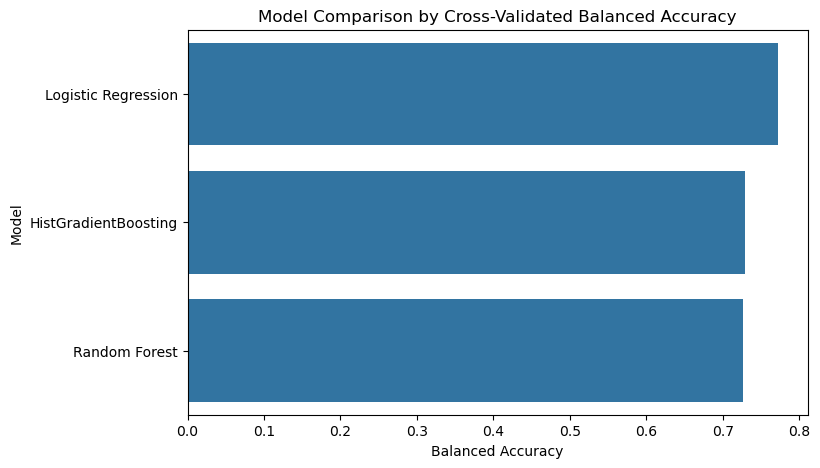

In [25]:
plt.figure(figsize=(8, 5))
sns.barplot(data=cv_results, x="cv_balanced_accuracy_mean", y="model")
plt.title("Model Comparison by Cross-Validated Balanced Accuracy")
plt.xlabel("Balanced Accuracy")
plt.ylabel("Model")
plt.show()

In [26]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 5, 10, 15],
    "classifier__min_samples_split": [2, 5, 10]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=cv,
    scoring="balanced_accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train, groups=train_groups)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)
print("Best CV Balanced Accuracy:", rf_grid.best_score_)

Best Random Forest Parameters:
{'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best CV Balanced Accuracy: 0.7373015873015872


In [28]:

hgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", HistGradientBoostingClassifier(random_state=42))
])

hgb_param_grid = {
    "classifier__learning_rate": [0.01, 0.05, 0.1],
    "classifier__max_depth": [None, 3, 5, 10],
    "classifier__max_iter": [100, 200, 300]
}

hgb_grid = GridSearchCV(
    estimator=hgb_pipeline,
    param_grid=hgb_param_grid,
    cv=cv,
    scoring="balanced_accuracy",
    n_jobs=-1
)

hgb_grid.fit(X_train, y_train, groups=train_groups)

print("Best HistGradientBoosting Parameters:")
print(hgb_grid.best_params_)
print("Best CV Balanced Accuracy:", hgb_grid.best_score_)

Best HistGradientBoosting Parameters:
{'classifier__learning_rate': 0.01, 'classifier__max_depth': 5, 'classifier__max_iter': 300}
Best CV Balanced Accuracy: 0.7559523809523809


In [29]:
tuned_results = pd.DataFrame([
    {
        "model": "Random Forest (Tuned)",
        "best_cv_balanced_accuracy": rf_grid.best_score_
    },
    {
        "model": "HistGradientBoosting (Tuned)",
        "best_cv_balanced_accuracy": hgb_grid.best_score_
    }
]).sort_values(by="best_cv_balanced_accuracy", ascending=False).reset_index(drop=True)

tuned_results

,model,best_cv_balanced_accuracy
0,HistGradientBoosting (Tuned),0.755952
1,Random Forest (Tuned),0.737302


In [31]:
best_model_name = tuned_results.loc[0, "model"]

print("Selected final model:", best_model_name)

Selected final model: HistGradientBoosting (Tuned)


In [33]:

y_test_pred = best_model.predict(X_test)

print("Final Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Final Test Balanced Accuracy:", balanced_accuracy_score(y_test, y_test_pred))
print("Final Test F1 Score:", f1_score(y_test, y_test_pred, average="weighted"))

print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))

Final Test Accuracy: 0.8157894736842105
Final Test Balanced Accuracy: 0.6524822695035462
Final Test F1 Score: 0.754870423481384

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       0.68      1.00      0.81        17
           2       0.90      0.96      0.93        47

    accuracy                           0.82        76
   macro avg       0.53      0.65      0.58        76
weighted avg       0.71      0.82      0.75        76



The final model was picked based on cross validated balanced accuracy after the hyperparameters were changed. If there is a mismatch in the classes, this is a better way to pick a model than just looking at how well it does on tests.

The last test from the set that was held out shows how well the model works with test data. You can get a better idea of how well each class predicts from the classification report 

## Conclusion

To keep the longitudinal structure of the dataset, subject names were taken out of the feature set while grouped splitting and grouped cross-validation were used to remove them. This kept data from getting out and made sure that the evaluation was based on performance on people who had not been seen, not on patient information that had been memorized.

Logistic Regression, Random Forest, and HistGradientBoosting were some of the models that were tested. The best models were then made even better by changing hyperparameters. The end model was chosen because it had balanced accuracy, which was right because the dataset had an imbalance of classes.

Overall, the results show that machine learning can help predict how well this dataset will work for classifying dementia. Still, things like small sample sizes, missing values, and unequal class sizes can affect results. More feature engineering, different classifiers, and more advanced methods for dealing with imbalances could be looked into in future research.